# Delta Debug Report Viewer

Load and visualize delta debug experiment reports.

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

if Path.cwd().name == "notebooks":
    ARTIFACTS = Path("../artifacts").resolve()
else:
    ARTIFACTS = (Path.cwd() / "artifacts").resolve()

print("ARTIFACTS:", ARTIFACTS)

## 1. Load Reports

In [ ]:
def load_reports(experiment_dir: Path) -> list[dict]:
    """Load all delta debug report JSONs from a directory."""
    reports = []
    for p in sorted(experiment_dir.glob("*.json")):
        with open(p, encoding="utf-8") as f:
            r = json.load(f)
        if "ddmin_log" not in r:
            continue
        r["_file"] = p.name
        reports.append(r)
    return reports

# Auto-select experiment with reports unless manually overridden
EXPERIMENT = None  # e.g. "grover3-1"

available = [d for d in sorted(ARTIFACTS.iterdir()) if d.is_dir()]
if not available:
    raise FileNotFoundError(f"No experiment directories under {ARTIFACTS}")

if EXPERIMENT:
    experiment_dir = ARTIFACTS / EXPERIMENT
else:
    candidates = []
    for d in available:
        jsons = list(d.glob("*.json"))
        if not jsons:
            continue
        newest = max(jsons, key=lambda p: p.stat().st_mtime)
        candidates.append((newest.stat().st_mtime, d))
    if not candidates:
        raise FileNotFoundError(f"No report JSON files found under {ARTIFACTS}/*")
    experiment_dir = sorted(candidates, key=lambda x: x[0])[-1][1]

experiment = experiment_dir.name
reports = load_reports(experiment_dir)
print(f"Loaded {len(reports)} reports from {experiment}")

if not reports:
    raise RuntimeError(f"No valid report JSON with ddmin_log in {experiment_dir}")

for r in reports:
    baseline = next((e for e in r.get("ddmin_log", []) if e.get("action") == "baseline"), None)
    baseline_loss = baseline.get("loss") if baseline else None
    print(
        f"  {r['_file']}  segments={len(r.get('segments_info', []))}  "
        f"baseline_loss={baseline_loss if baseline_loss is not None else 'N/A'}  "
        f"problematic={r.get('problematic_segments', [])}"
    )

## 2. DDMin Progress (Single Report)

Shows how the loss changes over DDMin iterations.

In [ ]:
def plot_ddmin_progress(report, ax=None):
    """Plot loss over DDMin iterations."""
    log = report.get("ddmin_log", [])
    if not log:
        raise RuntimeError(f"No ddmin_log in report: {report.get('_file', '<unknown>')}")

    losses = [e.get("loss", 0.0) for e in log]
    actions = [e.get("action", "unknown") for e in log]
    progressed = [e.get("progressed", False) for e in log]

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))

    colors = []
    for a, p in zip(actions, progressed):
        if a == "baseline":
            colors.append("black")
        elif p:
            colors.append("red")
        else:
            colors.append("steelblue")

    ax.bar(range(len(losses)), losses, color=colors, alpha=0.8)
    ax.set_xlabel("Test #")
    ax.set_ylabel("TVD Loss")
    ax.set_title(report.get("_file", "report"))
    ax.axhline(y=losses[0], color="gray", linestyle="--", alpha=0.5, label="baseline")

    legend = [
        mpatches.Patch(color="black", label="Baseline"),
        mpatches.Patch(color="red", label="Progressed"),
        mpatches.Patch(color="steelblue", label="No progress"),
    ]
    ax.legend(handles=legend, loc="upper right")
    return ax

# Plot first report safely
if reports:
    plot_ddmin_progress(reports[0])
    plt.tight_layout()
    plt.show()
else:
    print("No reports to plot.")

## 3. All Reports Overview

Compare DDMin progress across all reports in this experiment.

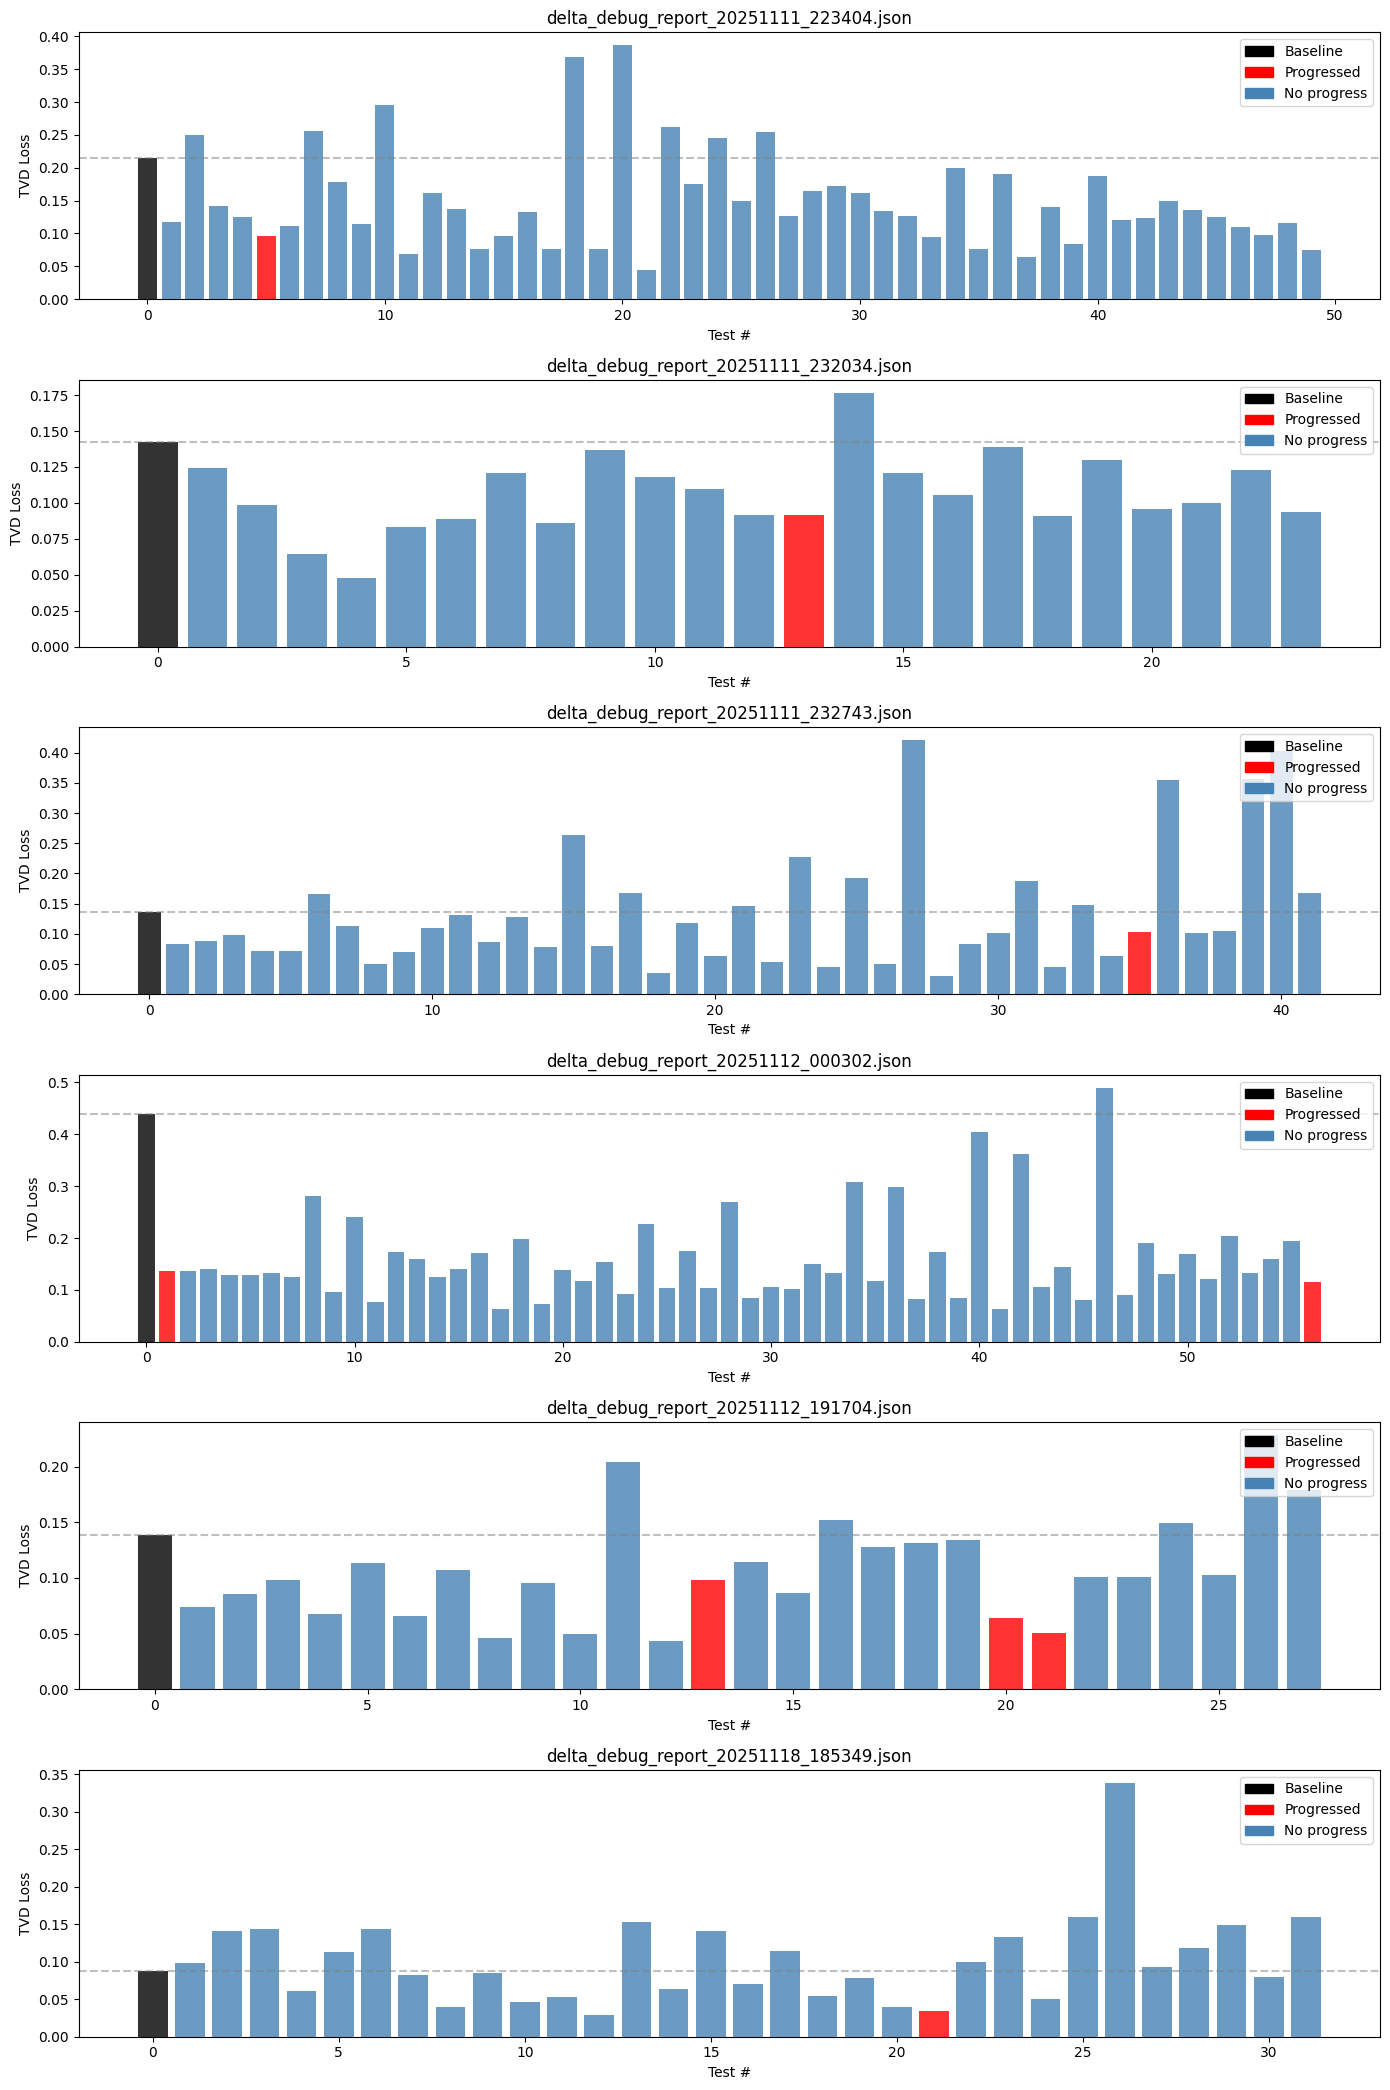

In [4]:
n = len(reports)
if n > 1:
    fig, axes = plt.subplots(n, 1, figsize=(14, 3.5 * n), sharex=False)
    for ax, r in zip(axes, reports):
        plot_ddmin_progress(r, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print("Only 1 report, see chart above.")

## 4. Problematic Segments Detail

Which segments were identified as problematic and what operations they contain.

In [5]:
def show_problematic_segments(report):
    """Display details of problematic segments."""
    print(f"=== {report['_file']} ===")
    segments_info = report["segments_info"]
    for idx in report["problematic_segments"]:
        seg = segments_info[idx]
        qubits = set()
        ops = {}
        for inst in seg["instructions"]:
            qubits.update(inst["qubits"])
            ops[inst["operation"]] = ops.get(inst["operation"], 0) + 1
        op_str = ", ".join(f"{v}x{k}" for k, v in ops.items())
        print(f"  Segment {idx}: qubits={sorted(qubits)}  "
              f"gates={seg['complexity']['total_gates']} "
              f"(2q={seg['complexity']['two_qubit_gates']})  "
              f"ops=[{op_str}]")
    print()

for r in reports:
    show_problematic_segments(r)

=== delta_debug_report_20251111_223404.json ===
  Segment 0: qubits=[136, 142]  gates=5 (2q=0)  ops=[3xrz, 2xsx]
  Segment 1: qubits=[142, 143, 144]  gates=5 (2q=0)  ops=[4xrz, 1xsx]
  Segment 2: qubits=[136, 142, 143, 144]  gates=5 (2q=0)  ops=[1xsx, 4xrz]
  Segment 3: qubits=[136, 143]  gates=2 (2q=1)  ops=[1xsx, 1xcz]
  Segment 4: qubits=[136, 143]  gates=4 (2q=1)  ops=[2xsx, 1xrz, 1xcz]
  Segment 5: qubits=[142, 143]  gates=4 (2q=1)  ops=[2xsx, 1xrz, 1xcz]
  Segment 6: qubits=[142, 143]  gates=4 (2q=1)  ops=[2xsx, 1xrz, 1xcz]
  Segment 7: qubits=[136, 142, 143]  gates=4 (2q=1)  ops=[2xsx, 1xrz, 1xcz]
  Segment 8: qubits=[142, 143]  gates=4 (2q=1)  ops=[2xsx, 1xrz, 1xcz]
  Segment 9: qubits=[136, 143]  gates=4 (2q=1)  ops=[2xsx, 1xrz, 1xcz]

=== delta_debug_report_20251111_232034.json ===
  Segment 0: qubits=[136, 142]  gates=5 (2q=0)  ops=[3xrz, 2xsx]
  Segment 1: qubits=[142, 143, 144]  gates=5 (2q=0)  ops=[4xrz, 1xsx]
  Segment 2: qubits=[136, 142, 143, 144]  gates=5 (2q=0)  ops=

## 5. Segment Heatmap

Which segments are problematic across runs? Darker = more frequently flagged.

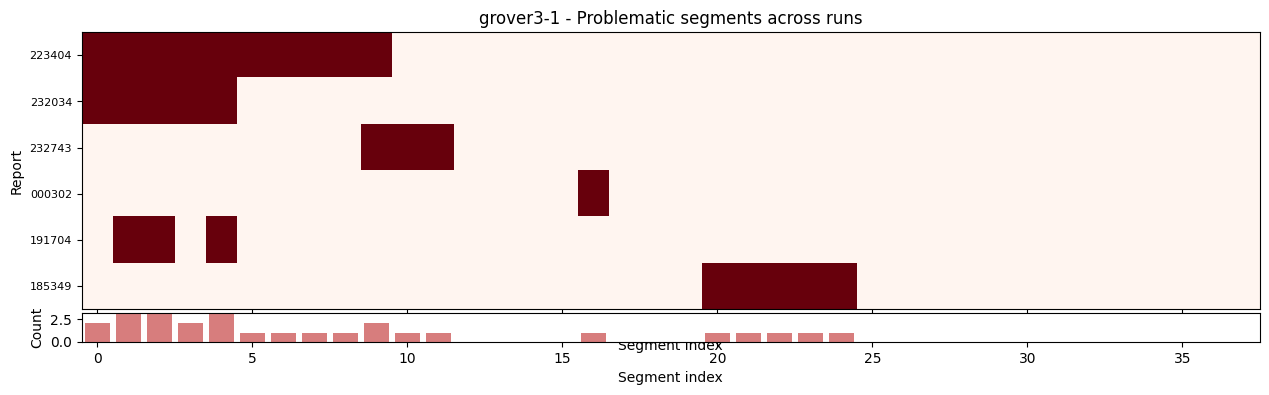

In [6]:
max_seg = max(len(r["segments_info"]) for r in reports)
matrix = np.zeros((len(reports), max_seg))
for i, r in enumerate(reports):
    for idx in r["problematic_segments"]:
        matrix[i, idx] = 1

fig, ax = plt.subplots(figsize=(max(12, max_seg * 0.4), max(2, len(reports) * 0.6)))
im = ax.imshow(matrix, aspect="auto", cmap="Reds", interpolation="nearest")
ax.set_xlabel("Segment index")
ax.set_ylabel("Report")
ax.set_yticks(range(len(reports)))
ax.set_yticklabels([r["_file"].split("_")[-1].replace(".json", "") for r in reports], fontsize=8)
ax.set_title(f"{experiment} - Problematic segments across runs")

# Frequency bar at bottom
freq = matrix.sum(axis=0)
ax2 = fig.add_axes([ax.get_position().x0, 0.02, ax.get_position().width, 0.08])
ax2.bar(range(max_seg), freq, color="indianred", alpha=0.8)
ax2.set_xlim(-0.5, max_seg - 0.5)
ax2.set_ylabel("Count")
ax2.set_xlabel("Segment index")

plt.show()

## 6. Baseline Loss Comparison

How does baseline loss vary across experiments?

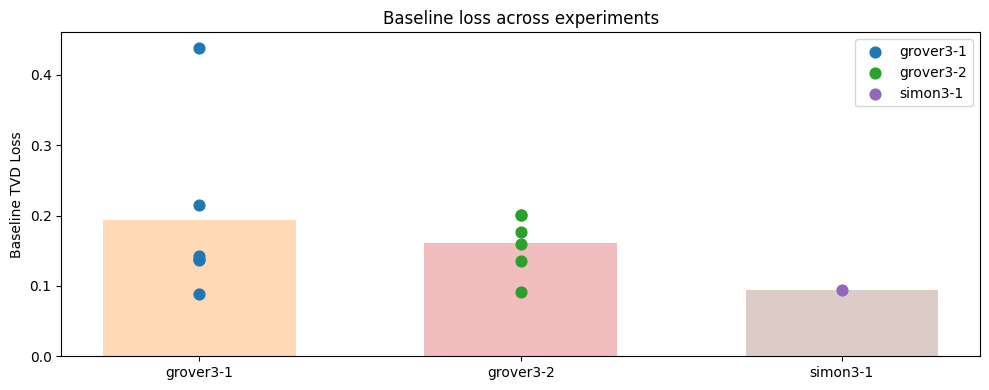

In [7]:
# Load all experiments
all_experiments = {}
for d in sorted(ARTIFACTS.iterdir()):
    if d.is_dir():
        rs = load_reports(d)
        if rs:
            all_experiments[d.name] = rs

fig, ax = plt.subplots(figsize=(10, 4))
for i, (name, rs) in enumerate(all_experiments.items()):
    baselines = []
    for r in rs:
        b = next(e for e in r["ddmin_log"] if e["action"] == "baseline")
        baselines.append(b["loss"])
    x = [i] * len(baselines)
    ax.scatter(x, baselines, s=60, zorder=3, label=name)
    ax.bar(i, np.mean(baselines), alpha=0.3, width=0.6)

ax.set_xticks(range(len(all_experiments)))
ax.set_xticklabels(all_experiments.keys())
ax.set_ylabel("Baseline TVD Loss")
ax.set_title("Baseline loss across experiments")
ax.legend()
plt.tight_layout()
plt.show()